# Notebook de Entrenamiento: Reconocimiento Facial

## Equipo
- Alumno 1: Juan Andres Morales
- Alumno 2: Genaro Canciani

## 1. Configuración e Instalación
Instalamos las librerías necesarias para el preprocesamiento y entrenamiento.

In [ ]:
# import subprocess, sys
# subprocess.run([
#     "uv", "pip", "install",
#     "torch", "torchvision", "torchaudio",
#     "--index-url", "https://download.pytorch.org/whl/cu124",
#     "--upgrade"
# ], check=True)


In [2]:
import torch
print(torch.__version__)               # debe decir algo como 2.x.x+cu124
print(torch.cuda.is_available())       # True
print(torch.cuda.get_device_name(0))   # NVIDIA GeForce RTX 3070

2.6.0+cu124
True
NVIDIA GeForce RTX 3070


## 2. Descarga del Dataset LFW
Descargamos el dataset Labeled Faces in the Wild, filtrando aquellas personas que tengan al menos 20 imágenes para asegurar suficientes datos de entrenamiento por clase.

In [3]:
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt
import numpy as np

# Descargamos LFW (esto puede tardar unos segundos la primera vez)
lfw = fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=True, slice_=None)
n_samples, h, w, c = lfw.images.shape
n_classes = len(lfw.target_names)

print(f"Total de imágenes originales: {n_samples}")
print(f"Cantidad de personas (clases): {n_classes}")
print(f"Resolución original: {h}x{w}")

Total de imágenes originales: 3023
Cantidad de personas (clases): 62
Resolución original: 250x250


## 3. Preprocesamiento (Alineación con InsightFace)
**Justificación:** Extraemos únicamente la zona del rostro y lo alineamos usando los landmarks de InsightFace o un fallback de bounding box si los landmarks fallan. Esto reduce el ruido de fondo y garantiza que la red se enfoque puramente en la identidad facial, siendo robusto a las limitaciones de detección del hardware.

In [4]:
from insightface.app import FaceAnalysis
from insightface.utils import face_align
import cv2
from tqdm import tqdm
import numpy as np
import os

# --- 1. SIEMPRE inicializamos 'app' y 'safe_crop_face' porque se usan más adelante ---
print("Inicializando InsightFace (CPU)...")
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0)

def safe_crop_face(img_bgr, face):
    if face.kps is not None:
        aligned = face_align.norm_crop(img_bgr, landmark=face.kps, image_size=112)
        if aligned is not None and aligned.size > 0:
            return aligned
    
    if face.bbox is not None:
        x1, y1, x2, y2 = face.bbox.astype(int)
        h, w = img_bgr.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size > 0:
            return cv2.resize(crop, (112, 112))
    return None

# --- 2. Lógica de carga rápida o procesamiento pesado ---
procesado_img_path = 'lfw_clean_images.npy'
procesado_lbl_path = 'lfw_clean_labels.npy'

if os.path.exists(procesado_img_path) and os.path.exists(procesado_lbl_path):
    print("¡Archivos encontrados! Cargando imágenes procesadas directamente desde el disco...")
    clean_images = list(np.load(procesado_img_path))
    clean_labels = list(np.load(procesado_lbl_path))
    print(f"LFW cargado exitosamente: {len(clean_images)} imágenes")

else:
    print("No se encontraron archivos en disco. Procesando LFW...")
    clean_images = []
    clean_labels = []

    print("Procesando y alineando LFW...")
    for i in tqdm(range(n_samples)):
        img_rgb = (lfw.images[i] * 255).astype(np.uint8)
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        
        faces = app.get(img_bgr)
        if len(faces) > 0:
            face = faces[0]
            aligned_face_bgr = safe_crop_face(img_bgr, face)
            
            if aligned_face_bgr is not None:
                aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                clean_images.append(aligned_face_rgb)
                clean_labels.append(lfw.target[i])

    print(f"\nLFW procesado exitosamente: {len(clean_images)} de {n_samples}")
    
    print("Guardando imágenes procesadas en disco para futuros usos...")
    np.save(procesado_img_path, np.array(clean_images))
    np.save(procesado_lbl_path, np.array(clean_labels))
    print("¡Guardado completado!")


Inicializando InsightFace (CPU)...


c:\Users\juanm\OneDrive\Documentos\TUIA\CV\tuia-face-recognition-app\.venv\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:148: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\juanm/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\juanm/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\juanm/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\juanm/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\juanm/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

### Dataset Propio
Procesamos nuestro dataset propio usando la misma lógica de recorte robusto.

In [5]:
import os
from pathlib import Path

custom_data_path = Path("src/data/dataset_propio") 
custom_images = []
custom_labels = []
current_label_id = n_classes 
custom_target_names = []

if custom_data_path.exists():
    print("Procesando dataset propio...")
    for person_folder in custom_data_path.iterdir():
        if person_folder.is_dir():
            person_name = person_folder.name
            custom_target_names.append(person_name)
            
            archivos = list(person_folder.glob("*.jpg")) + list(person_folder.glob("*.png")) + list(person_folder.glob("*.jpeg"))
            
            for img_path in archivos:
                img_bgr = cv2.imread(str(img_path))
                if img_bgr is None: continue
                
                faces = app.get(img_bgr)
                if len(faces) > 0:
                    face = faces[0]
                    aligned_face_bgr = safe_crop_face(img_bgr, face)
                    
                    if aligned_face_bgr is not None:
                        aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                        custom_images.append(aligned_face_rgb)
                        custom_labels.append(current_label_id)
            
            current_label_id += 1
            
    print(f"Caras propias procesadas y alineadas: {len(custom_images)}")
else:
    print("No se encontró la carpeta del dataset propio.")

all_images = clean_images + custom_images
all_labels = clean_labels + custom_labels
all_target_names = list(lfw.target_names) + custom_target_names

print(f"\nTotal final de imágenes listas para entrenar: {len(all_images)}")
print(f"Total de personas distintas (clases): {len(all_target_names)}")

Procesando dataset propio...


c:\Users\juanm\OneDrive\Documentos\TUIA\CV\tuia-face-recognition-app\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Caras propias procesadas y alineadas: 64

Total final de imágenes listas para entrenar: 3077
Total de personas distintas (clases): 71


## 4. Dataloaders y Data Augmentation
**Justificación:** Agregamos Data Augmentation (Flip, Rotación, ColorJitter) para aumentar la diversidad de las caras de nuestro dataset propio y reducir el sobreajuste (overfitting). Utilizamos las medias y desviaciones estándar requeridas por los modelos pre-entrenados en ImageNet.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image

class FaceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # PIL Image es requerido por algunas transformaciones
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Transformaciones para ENTRENAMIENTO (Data Augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones para VALIDACIÓN (Sin ruido)
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

X_train, X_val, y_train, y_val = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
val_dataset = FaceDataset(X_val, y_val, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last= True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Tamaño del set de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del set de validación: {len(val_dataset)}")


Tamaño del set de entrenamiento: 2461
Tamaño del set de validación: 616


In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2).clamp(0, 1))
        
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        output *= self.s
        return output
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2).clamp(0, 1))
        
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        output *= self.s
        return output

## 5. Arquitectura del Modelo (ResNet50 + Fine Tuning)
*Justificación Técnica*: Seleccionamos ResNet50 como backbone extractor de características, aprovechando sus pesos pre-entrenados (Transfer Learning) para una convergencia rápida y evitar el sobreajuste. Sin embargo, reemplazamos la clásica capa lineal de clasificación por un módulo ArcFace (Additive Angular Margin Loss). Mientras que la pérdida de entropía cruzada estándar (Cross-Entropy) agrupa las clases de forma débil, ArcFace impone un estricto margen angular matemático entre las distintas identidades durante el entrenamiento. Esto fuerza a la red a agrupar los rostros de una misma persona de forma extremadamente compacta (intra-class compactness) y a alejar radicalmente los clusters de personas diferentes en el espacio latente (inter-class discrepancy). El resultado final es un modelo que extrae embeddings de 512 dimensiones altamente discriminativos, reduciendo drásticamente los falsos positivos y siendo ideal para sistemas de reconocimiento facial de conjunto abierto (Open-Set).

In [8]:
import torch.nn as nn
from torchvision import models

class FaceRecognitionResNet(nn.Module):
    def __init__(self):
        super(FaceRecognitionResNet, self).__init__()
        self.backbone = models.resnet50(weights='DEFAULT')
        
        num_ftrs = self.backbone.fc.in_features
        
        # QUITAMOS la última capa Linear. Ahora el modelo devuelve el embedding directo.
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
    def forward(self, x):
        # Normalizamos el embedding que sale de la red
        x = self.backbone(x)
        return torch.nn.functional.normalize(x, p=2, dim=1)
        
    def extract_embedding(self, x):
        # En inferencia, solo necesitamos el forward normal
        return self.forward(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model = FaceRecognitionResNet()
model = model.to(device)

# Inicializamos ArcFace
arcface = ArcFace(in_features=512, out_features=len(all_target_names), s=30.0, m=0.50)
arcface = arcface.to(device)


Usando dispositivo: cuda


## 6. Bucle de Entrenamiento (Training Loop)
Ajustamos los pesos del modelo. Usamos `ArcFace` y el optimizador `Adam`.En este caso se realiza un Fine Tuning de la arquitectura completa para que el modelo (previamente entrenado con ImageNet, no para la detección facial) pueda adaptarse a extraer características de rostros. Se toma la decisión de utilizar un lr de 1e-4 para no destruir las características generales ya aprendidas por el modelo. 

La poca cantidad de épocas se debe a la rápida convergencia del modelo, logrando alcanzar una accuracy en validación de 92% en la primera iteración del loop de entrenamiento. 

In [9]:
import torch.optim as optim
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

criterion = nn.CrossEntropyLoss()

# El optimizador ahora recibe los parámetros del modelo Y de ArcFace
optimizer = optim.Adam([
    {'params': model.parameters()},
    {'params': arcface.parameters()}
], lr=0.0001)

num_epochs = 25

print("Iniciando entrenamiento con ArcFace...")
for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    arcface.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        embeddings = model(inputs)
        # Pasamos embeddings y labels por ArcFace antes de calcular la loss
        outputs = arcface(embeddings, labels)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    
    # Validación
    model.eval()
    arcface.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            embeddings = model(inputs)
            outputs = arcface(embeddings, labels)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time
    
    print(f"Época [{epoch+1}/{num_epochs}] - Tiempo: {epoch_time:.0f}s - "
          f"Loss: {running_loss/len(train_loader):.4f} - Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} - Val Acc: {val_acc:.2f}%")

Iniciando entrenamiento con ArcFace...
Época [1/25] - Tiempo: 11s - Loss: 18.4871 - Acc: 0.00% | Val Loss: 16.1849 - Val Acc: 0.00%
Época [2/25] - Tiempo: 8s - Loss: 15.5151 - Acc: 1.15% | Val Loss: 12.7548 - Val Acc: 22.40%
Época [3/25] - Tiempo: 9s - Loss: 13.0561 - Acc: 11.97% | Val Loss: 10.6133 - Val Acc: 26.79%
Época [4/25] - Tiempo: 9s - Loss: 11.1355 - Acc: 17.52% | Val Loss: 8.7931 - Val Acc: 38.31%
Época [5/25] - Tiempo: 9s - Loss: 9.5819 - Acc: 21.46% | Val Loss: 7.3532 - Val Acc: 43.99%
Época [6/25] - Tiempo: 8s - Loss: 8.2816 - Acc: 24.42% | Val Loss: 6.0869 - Val Acc: 48.86%
Época [7/25] - Tiempo: 9s - Loss: 7.1961 - Acc: 26.77% | Val Loss: 4.9344 - Val Acc: 57.31%
Época [8/25] - Tiempo: 9s - Loss: 6.3088 - Acc: 30.06% | Val Loss: 3.9739 - Val Acc: 62.66%
Época [9/25] - Tiempo: 8s - Loss: 5.5388 - Acc: 32.15% | Val Loss: 3.2057 - Val Acc: 70.29%
Época [10/25] - Tiempo: 9s - Loss: 4.8696 - Acc: 33.47% | Val Loss: 2.7992 - Val Acc: 76.62%
Época [11/25] - Tiempo: 9s - Loss: 

## 7. Evaluación: Métricas y Embeddings (PCA / t-SNE)
Validamos que el modelo haya aprendido a separar las identidades en el espacio vectorial.

In [10]:
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels_val = []
all_embeddings = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device) # Mover labels a gpu
        
        # 1. El modelo solo saca los 512 números (el embedding)
        embeddings = model(inputs)
        
        # 2. ArcFace compara esos 512 números contra los 71 "centros" de identidades
        # y saca las 71 predicciones
        outputs = arcface(embeddings, labels)
        
        # 3. AHORA SÍ, sacamos el índice de la persona con mayor probabilidad (0 a 70)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels_val.extend(labels.cpu().numpy())
        all_embeddings.extend(embeddings.cpu().numpy())


# --- Classification Report (Accuracy, Precision, Recall) ---
print("Classification Report:")
print(classification_report(all_labels_val, all_preds, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       1.00      0.86      0.92         7
           2       0.67      0.50      0.57         4
           3       0.88      1.00      0.93         7
           4       0.67      0.50      0.57         4
           5       0.71      0.94      0.81        16
           6       0.78      0.88      0.82         8
           7       1.00      0.60      0.75         5
           8       0.86      1.00      0.92         6
           9       0.60      0.75      0.67         4
          10       1.00      0.94      0.97        47
          11       0.80      0.67      0.73         6
          12       1.00      1.00      1.00        24
          13       0.80      1.00      0.89         4
          14       0.93      0.99      0.96       106
          15       0.96      1.00      0.98        22
          16       0.88      0.78      0.82         9
    

Calculando t-SNE en 2D...


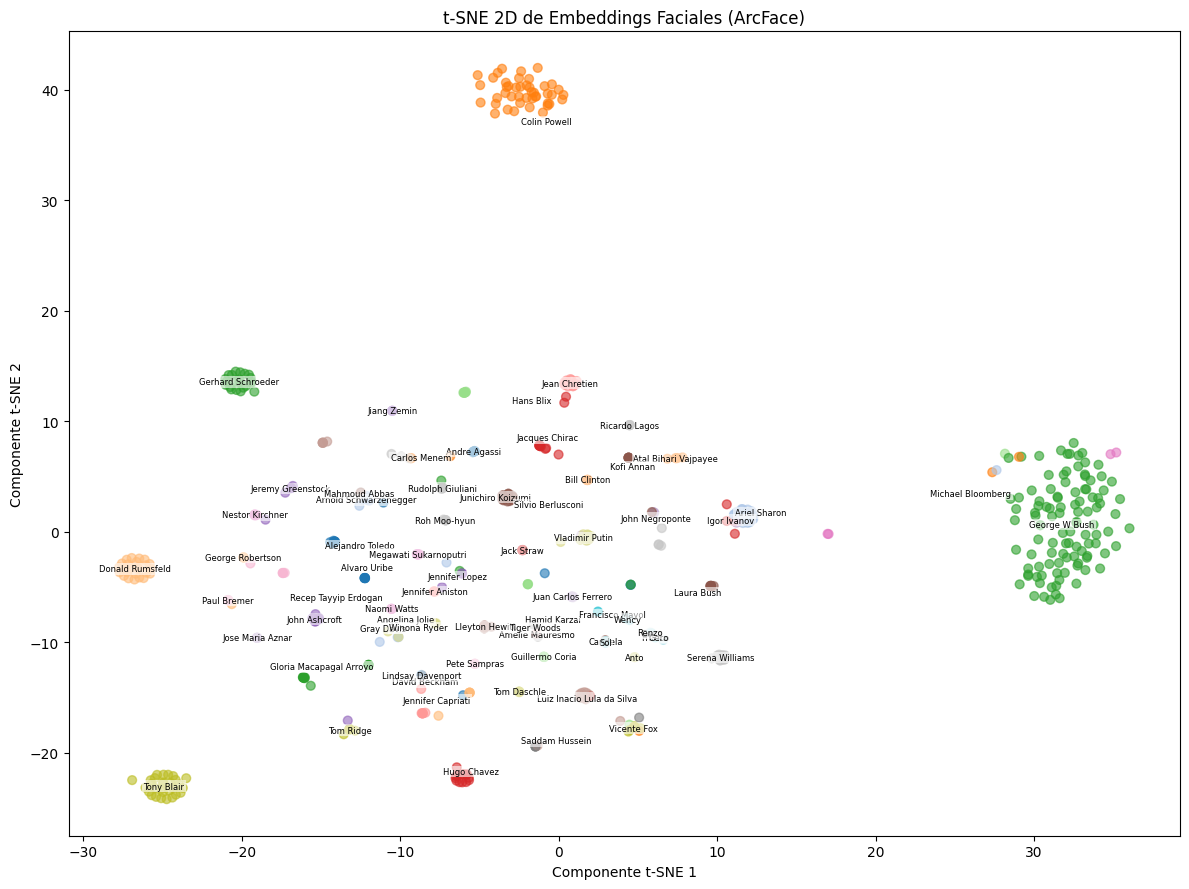

In [11]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Convertimos a arrays por las dudas
all_embeddings_np = np.array(all_embeddings)
all_labels_np = np.array(all_labels_val)

print("Calculando t-SNE en 2D...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(all_embeddings_np)

plt.figure(figsize=(12, 9))

# Dibujamos los puntos
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=all_labels_np, cmap='tab20', alpha=0.6, s=40)

# Agregamos los nombres en el centro de cada cluster para saber "quién es quién"
for i in np.unique(all_labels_np):
    idx = all_labels_np == i
    
    # Centro aproximado de los puntos de esta persona
    x_center = np.mean(tsne_result[idx, 0])
    y_center = np.mean(tsne_result[idx, 1])
    
    nombre = all_target_names[i]
    
    # Ponemos el texto con un fondito semi-transparente para que se lea bien
    plt.text(x_center, y_center, nombre, fontsize=6, ha='center', va='center', 
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.title("t-SNE 2D de Embeddings Faciales (ArcFace)")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.tight_layout()
plt.show()

## 8. Guardar el Modelo para el Backend
Exportamos el archivo `.pth` en la carpeta `models/` para que el backend (`face_service.py`) lo pueda levantar.

In [12]:
import os
os.makedirs("models", exist_ok=True)

# Guardamos únicamente los pesos (state_dict) del modelo entrenado
torch.save(model.state_dict(), "models/face_detection.pth")
print("¡Modelo exportado exitosamente a models/face_detection.pth!")

¡Modelo exportado exitosamente a models/face_detection.pth!


# Carga dataset propio a base de datos 

In [ ]:
import requests
import time
from pathlib import Path

# Configuración de tu backend local
BACKEND_URL = "http://localhost:8000"
# Ruta a tu dataset propio (ajustar si es necesario)
custom_data_path = Path("src/data/dataset_propio")

def registrar_identidades_en_bd():
    if not custom_data_path.exists():
        print(f"La ruta {custom_data_path} no existe.")
        return

    print("Iniciando la carga de embeddings a la base de datos vía API...")
    
    for person_folder in custom_data_path.iterdir():
        if person_folder.is_dir():
            identity = person_folder.name
            
            # Tomar todas las imágenes de la persona
            archivos = list(person_folder.glob("*.jpg")) + list(person_folder.glob("*.png")) + list(person_folder.glob("*.jpeg"))
            
            for img_path in archivos:
                # 1. Armamos el payload esperado por el endpoint /insert
                payload = {
                    "identity": identity,
                    "image_path": str(img_path.absolute()), # La API necesita un path absoluto o válido
                    "metadata": {"fuente": "dataset_propio", "notebook_sync": True}
                }
                
                try:
                    # 2. Hacemos el POST al endpoint asincrónico
                    response = requests.post(f"{BACKEND_URL}/insert", json=payload)
                    
                    if response.status_code == 202:
                        job_id = response.json().get("job_id")
                        print(f"[{identity}] Job encolado con ID: {job_id} para la imagen {img_path.name}")
                        
                        # Opcional: Podrías hacer polling al /status/{job_id} para asegurarte de que terminó, 
                        # pero al ser una carga inicial, basta con enviarlos todos.
                        time.sleep(0.1) # Pequeño delay para no saturar el TaskManager del backend
                    else:
                        print(f"Error al registrar {identity}: {response.text}")
                        
                except requests.exceptions.ConnectionError:
                    print("Error de conexión: Asegúrate de que el backend esté corriendo en http://localhost:8000")
                    return

    print("\n¡Proceso de registro finalizado!")

# Llamar a la función para registrar
registrar_identidades_en_bd()
